<a href="https://colab.research.google.com/github/JustinMann123/EMSC2010_W2_P1_NB1_u8350605.ipynb/blob/main/EMSC2010_W9_GRACE_IceDiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 – Ice Mass Redistribution Model
## Using GRACE-FO Mascon Data (November 2022)

### Background

The [GRACE-FO](https://gracefo.jpl.nasa.gov/) (Gravity Recovery and Climate Experiment Follow-On)
satellite mission measures tiny changes in Earth's gravity field caused by the movement of mass —
primarily water and ice. From these gravity measurements we can derive **Equivalent Water Height (EWH)**:
the thickness of a layer of water that would produce the same gravity signal as the observed mass change.

Over Greenland, large negative EWH anomalies reveal where the ice sheet has lost mass relative to
a baseline period. In November 2022, significant negative anomalies exceeding −10 m EWH are visible
across the southern and western margins of Greenland — regions of well-documented accelerating ice loss.

### The Model

We will simulate how this mass anomaly **redistributes** over time using the same mathematical
framework as heat diffusion — the **diffusion equation**:

$$\frac{\partial H}{\partial t} = D\,\frac{\partial^2 H}{\partial x^2}$$

where:

- $H$ is the ice/mass column height (m of EWH), one value per mascon along the transect
- $D$ is the **ice flow diffusivity** (m²/s), which controls how quickly mass spreads
- $x$ is horizontal distance along the transect (m)
- $t$ is time (s)

The discrete update rule applied at each time step is:

$$H_i^{\mathrm{new}} = H_i + D\,\frac{\Delta t}{(\Delta x)^2}\bigl(H_{i+1} - 2H_i + H_{i-1}\bigr)$$

This is **identical** in form to the soil temperature model — if a mascon's neighbours hold more
mass than it does, mass flows in; if they hold less, mass flows out. The rate is controlled by $D$.

Key aspects of the model:

1. **The transect** — a 1-D slice of GRACE mascon EWH values extracted from the Greenland cluster,
   representing a profile across the ice sheet.
2. **Boundary conditions** — the first and last mascons are held fixed at 0 m EWH (open ocean /
   ice-free margin).
3. **The update rule** — at each time step every interior mascon adjusts its EWH based on its
   neighbours, as above.


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d


### Step 1 — Load the GRACE-FO mascon data

The `.ewh` file is a VCV-format text file produced by geodetic processing software.
Each line records one mascon parameter: its index, a priori value, estimated value,
and formal uncertainty (sigma). We parse the estimated EWH values (column 3) in metres.


In [2]:
# ── Parse the GRACE-FO EWH file ──────────────────────────────────────────────
ewh_file = 'GRACE_FO_2022-11.ewh'   # update path if needed

all_ewh = []
with open(ewh_file) as f:
    for line in f:
        m = re.match(
            r'\s*\d+\.\s+MC\d+\s+\(m\)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)', line
        )
        if m:
            all_ewh.append(float(m.group(2)))   # column 2 = estimate

all_ewh = np.array(all_ewh)
print(f'Total mascons parsed: {len(all_ewh)}')
print(f'Global EWH range: {all_ewh.min():.3f} m  to  {all_ewh.max():.3f} m')


Total mascons parsed: 12754
Global EWH range: -10.744 m  to  2.241 m


### Step 2 — Extract the Greenland transect

The most strongly negative mascons (up to −10.7 m EWH) cluster around indices 9 400–9 700.
This corresponds to the Greenland ice sheet, where cumulative mass loss since the GRACE
baseline (2004–2009) is most severe. We extract a 50-mascon 1-D transect by smoothing and
sub-sampling this cluster, and shift the profile upward so that all values are ≥ 0 m
(necessary for a physically meaningful diffusion initial condition).


Transect length: 50 mascons
EWH range after shift: 0.000 m  to  3.451 m


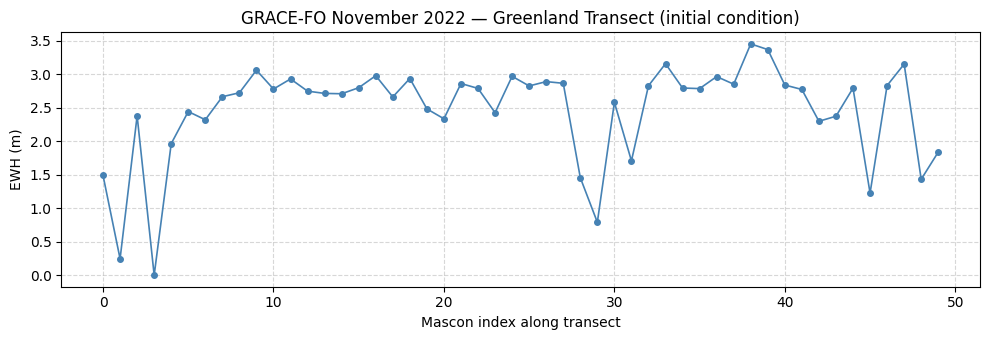

In [3]:
# ── Extract and prepare the Greenland 1-D profile ────────────────────────────
greenland_raw = all_ewh[9400:9700]                     # Greenland mascon cluster

# Light smoothing to remove noisy mascon-to-mascon scatter
greenland_smooth = uniform_filter1d(greenland_raw, size=6)

# Sub-sample to 50 points (every 6th mascon)
transect = greenland_smooth[::6][:50]

# Shift so the minimum value is 0 (model requires non-negative "ice height")
transect = transect - transect.min()

num_mascons = len(transect)
print(f'Transect length: {num_mascons} mascons')
print(f'EWH range after shift: {transect.min():.3f} m  to  {transect.max():.3f} m')

# Quick look at the raw profile
plt.figure(figsize=(10, 3.5))
plt.plot(transect, 'o-', color='steelblue', markersize=4, linewidth=1.2)
plt.xlabel('Mascon index along transect')
plt.ylabel('EWH (m)')
plt.title('GRACE-FO November 2022 — Greenland Transect (initial condition)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Step 3 — Define the model grid and ice flow diffusivity

Each mascon in the Greenland cluster covers roughly **50 km** at ~70 °N latitude.
We use this as our grid spacing $\Delta x$. The ice flow diffusivity $D$ captures
the effective rate at which ice (and therefore mass) spreads under gravity. A value
of $D \approx 100$ m²/s is representative of large-scale ice sheet flow.


In [4]:
# ── Model grid and physical parameters ───────────────────────────────────────
dx   = 50_000.0   # mascon spacing along transect (m) — approx. 50 km at 70°N
D    = 100.0      # ice flow diffusivity (m²/s)

# Spatial coordinate for plotting
x_km = np.arange(num_mascons) * dx / 1000   # convert to km

print(f'Transect length: {x_km[-1]:.0f} km')
print(f'Diffusivity D  : {D} m²/s')


Transect length: 2450 km
Diffusivity D  : 100.0 m²/s


### Step 4 — Set up the time stepping

We step the model forward in monthly increments over a 10-year period. This lets us
watch how the November 2022 mass distribution would evolve if ice flow alone were
redistributing the mass — a useful idealised scenario.


In [5]:
# ── Time parameters ───────────────────────────────────────────────────────────
dt        = 30 * 24 * 3600   # time step: 1 month in seconds
num_steps = 120              # 120 months = 10 years

# Check the stability condition BEFORE running
r = D * dt / dx**2
print(f'Stability ratio r = D·Δt/Δx² = {r:.4f}')
print(f'  (must be ≤ 0.5 for a stable solution)')
if r <= 0.5:
    print('  ✓ Model is numerically stable')
else:
    print('  ✗ UNSTABLE — reduce dt or increase dx')


Stability ratio r = D·Δt/Δx² = 0.1037
  (must be ≤ 0.5 for a stable solution)
  ✓ Model is numerically stable


### Step 5 — Apply initial and boundary conditions

- **Initial condition**: the GRACE-FO EWH transect for November 2022 (loaded above).
- **Boundary conditions**: both ends of the transect are fixed at 0 m EWH throughout
  the simulation, representing the open ocean / ice-free margin where ice thickness
  goes to zero.


In [6]:
# ── Initial and boundary conditions ─────────────────────────────────────────
H = transect.copy()   # EWH profile from GRACE (m)

# Enforce boundary conditions (margins fixed at 0)
H[0]  = 0.0
H[-1] = 0.0

# Storage for output (same pattern as the soil temperature model)
H_output = []
H_output.append(H.copy())   # record initial state (step 0)


### Step 6 — Run the time-stepping loop

At each step, every interior mascon updates its EWH based on the difference
between its neighbours' values and its own — exactly the same logic as the soil
temperature model, but now for ice mass.


In [7]:
# ── Time-stepping loop ────────────────────────────────────────────────────────
for step in range(1, num_steps + 1):

    H_new = H.copy()   # start from current state

    # Update every interior mascon (boundaries are fixed)
    for i in range(1, num_mascons - 1):
        H_new[i] = H[i] + D * (dt / dx**2) * (H[i+1] - 2*H[i] + H[i-1])

    H = H_new
    H_output.append(H.copy())

print(f'Model run complete: {num_steps} steps ({num_steps/12:.1f} years)')


Model run complete: 120 steps (10.0 years)


### Plot 1 — EWH profile at a chosen time step

Adjust `plot_step` to explore different stages of the model run:

- **Early steps**: only the shallowest parts of the profile have changed.
- **Middle steps**: the redistribution front has spread further along the transect.
- **Late steps / equilibrium**: a smooth parabolic profile — the steady-state shape
  for diffusion with zero-value boundary conditions.


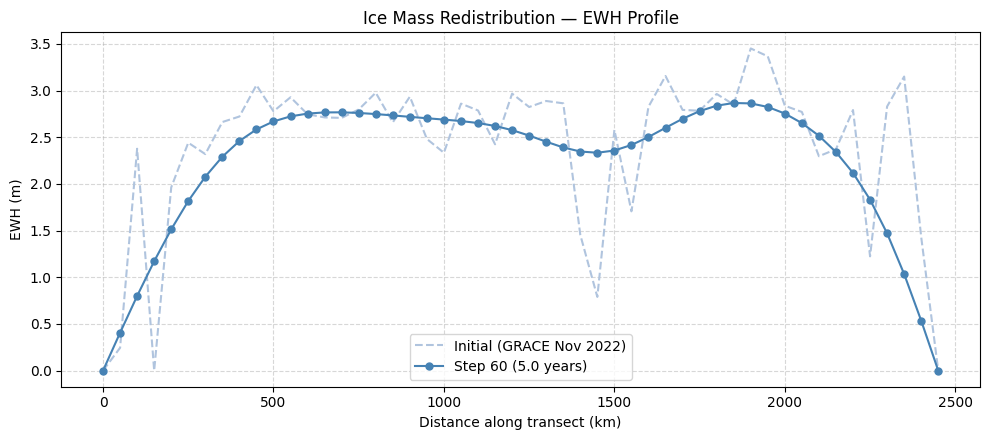

In [8]:
# ── Plot EWH profile at a chosen time step ───────────────────────────────────
plot_step = 60   # choose any step between 0 and num_steps

plt.figure(figsize=(10, 4.5))
plt.plot(x_km, H_output[0],         '--', color='lightsteelblue',
         linewidth=1.5, label='Initial (GRACE Nov 2022)')
plt.plot(x_km, H_output[plot_step], 'o-', color='steelblue',
         markersize=5, linewidth=1.5,
         label=f'Step {plot_step} ({plot_step/12:.1f} years)')
plt.xlabel('Distance along transect (km)')
plt.ylabel('EWH (m)')
plt.title('Ice Mass Redistribution — EWH Profile')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


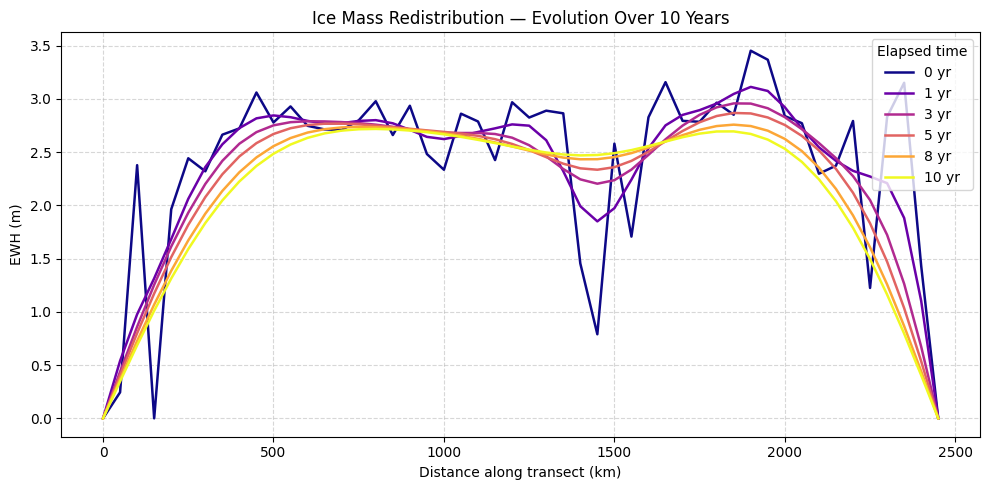

In [9]:
# ── Overlay multiple time steps to show evolution ────────────────────────────
steps_to_plot = [0, 12, 36, 60, 96, 120]   # months → 0, 1, 3, 5, 8, 10 years
cmap = plt.cm.plasma
colours = [cmap(i / (len(steps_to_plot)-1)) for i in range(len(steps_to_plot))]

plt.figure(figsize=(10, 5))
for s, col in zip(steps_to_plot, colours):
    plt.plot(x_km, H_output[s], '-', color=col,
             linewidth=1.8, label=f'{s/12:.0f} yr')

plt.xlabel('Distance along transect (km)')
plt.ylabel('EWH (m)')
plt.title('Ice Mass Redistribution — Evolution Over 10 Years')
plt.legend(title='Elapsed time', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Plot 2 — EWH time series at a single mascon

We can also track how the EWH at one mascon evolves through the simulation,
analogous to tracking a single soil layer's temperature through time.


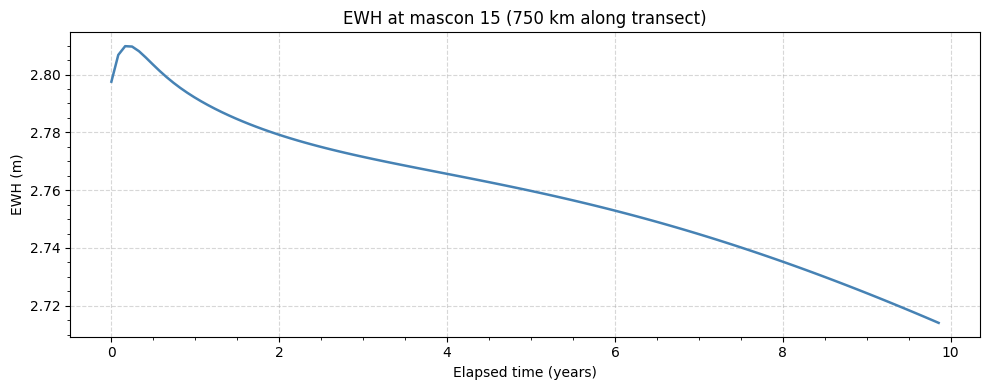

In [10]:
# ── EWH time series at a chosen mascon ───────────────────────────────────────
mascon_idx = 15   # index of the mascon to track (0 to num_mascons-1)

time_series = [H[mascon_idx] for H in H_output]
time_years  = np.arange(0, num_steps + 1) * dt / (365.25 * 24 * 3600)

plt.figure(figsize=(10, 4))
plt.plot(time_years, time_series, color='steelblue', linewidth=1.8)
plt.xlabel('Elapsed time (years)')
plt.ylabel('EWH (m)')
plt.title(f'EWH at mascon {mascon_idx} ({x_km[mascon_idx]:.0f} km along transect)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()


### Experiments

Now that the model is running, try the following:

**1. How does ice flow diffusivity control the redistribution timescale?**  
Compare the time to reach equilibrium for three scenarios:

| Scenario | D (m²/s) | Physical analogue |
|---|---|---|
| Slow (cold, dry-based ice) | 10 | Very sluggish interior flow |
| Typical (warm-based ice) | 100 | Standard ice sheet flow |
| Fast (ice stream) | 1000 | Outlet glacier / ice stream |

Change `D` in the grid setup cell and re-run the loop. How many years does each
take to approach a smooth equilibrium profile?

**2. What happens if you reverse the boundary conditions?**  
Set `H[0] = 5.0` and `H[-1] = 0.0`. How does the equilibrium shape change?
How is this analogous to reversing the bottom temperature in the soil model?

**3. Connection to your GPS data**  
The GPS elevation time series you plotted earlier shows **bedrock rising** as
ice mass is lost. This is the *isostatic response* to the GRACE mass anomaly.
How might you expect the rate of bedrock uplift to change over the 10-year
simulation period as mass redistributes?


### Numerical Stability

Just as in the soil temperature model, our diffusion scheme has a **stability condition**:

$$\Delta t \leq \frac{(\Delta x)^2}{2D}$$

The ratio $r = D\,\Delta t / (\Delta x)^2$ must stay at or below **0.5**.

If it exceeds 0.5 the scheme becomes unstable — each mascon overcorrects relative
to its neighbours, oscillations grow, and the solution becomes meaningless.

Try doubling `dt` (to 2 months) and observe the instability. Then restore it and try
increasing `D` to 5 000 m²/s. What is the maximum stable `dt` for that diffusivity?

This constraint is the same fundamental trade-off as in the soil model:
finer spatial resolution (smaller $\Delta x$) forces a much shorter time step —
the computational cost scales as $(\Delta x)^{-2}$, making high-resolution
ice sheet modelling genuinely expensive.


### Bonus — Visualise the full space-time evolution as a heatmap


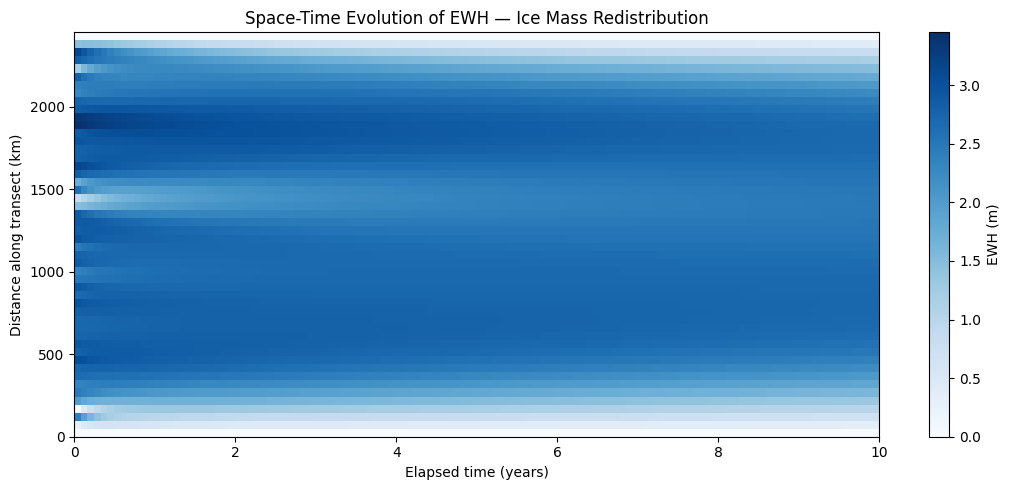

In [11]:
# ── Space-time heatmap ────────────────────────────────────────────────────────
H_matrix = np.array(H_output)   # shape: (num_steps+1, num_mascons)

plt.figure(figsize=(11, 5))
plt.imshow(
    H_matrix.T,
    aspect='auto',
    origin='lower',
    extent=[0, num_steps/12, x_km[0], x_km[-1]],
    cmap='Blues'
)
cb = plt.colorbar(label='EWH (m)')
plt.xlabel('Elapsed time (years)')
plt.ylabel('Distance along transect (km)')
plt.title('Space-Time Evolution of EWH — Ice Mass Redistribution')
plt.tight_layout()
plt.show()
